# Exploratory Data Analysis For Titanic Dataset

Step 1: Importing Libraries

In [ ]:
import numpy as np  # Import the NumPy library for numerical operations and array manipulation.
import pandas as pd  # Import the Pandas library for data manipulation and analysis, especially with DataFrames.
import matplotlib.pyplot as plt  # Import Matplotlib's pyplot module for creating static, interactive, and animated visualizations.
import seaborn as sns  # Import Seaborn for statistical data visualization, built on Matplotlib and integrated with Pandas data structures.

Step 2: Loading The Dataset

In [ ]:
# Import the files module from google.colab to handle file uploads
from google.colab import files

# Create an uploader widget and get the uploaded files
uploaded = files.upload()

# Get the name of the uploaded file
file_name = next(iter(uploaded))

# Load the uploaded CSV file into a pandas DataFrame
df = pd.read_csv(file_name)

# Display the first 5 rows of the DataFrame to confirm successful loading
print(f"Successfully loaded {file_name} into a DataFrame.")
display(df.head())

Saving Titanic dataset.csv to Titanic dataset.csv
Successfully loaded Titanic dataset.csv into a DataFrame.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


STEP 3: UNDERSTANDING THE DATASET

In [ ]:
df.tail() #To dispaly the last five rows in the dataset

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
417,1309,0,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


In [ ]:
df.shape #To show the number of rows and columns in the dataset

(418, 12)

In [ ]:
df.columns #To display all the columns in the dataset

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Data Dictionary:

PassengerId: A unique identification number assigned to each passenger.

Survived: Indicates whether the passenger survived (1) or not (0).

Pclass: Represents the passenger's class (1st, 2nd, or 3rd class).

Name: The name of the passenger.

Sex: The gender of the passenger (male or female).

Age: The age of the passenger in years.

SibSp: The number of siblings (brothers, sisters) or spouses aboard the Titanic with the passenger.

Parch: The number of parents or children aboard the Titanic with the passenger.

Ticket: The ticket number.

Fare: The fare paid by the passenger.

Cabin: The cabin number where the passenger stayed.

Embarked: The port where the passenger embarked (C = Cherbourg, Q = Queenstown, S = Southampton).


In [ ]:
df.dtypes #To show the data types of all the columns

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [ ]:
df.info() #To show columns and the number of non-blank entries

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [ ]:
df.isnull().sum() #To show the total number of blank cells in the dataset

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1


In [ ]:
df.describe() #to display the statistiacl summary of the dataset

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


STEP 4: DATA CLEANING

In [ ]:
#To handle missing values. Relace missing age and fare with median and missing cabin with unknown
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Fare'].fillna(df['Fare'].median(), inplace=True)
df['Cabin'].fillna('Unknown', inplace=True)

/tmp/ipykernel_1531/523272614.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_1531/523272614.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df.duplicated().sum() #To check for duplicate rows
df.drop_duplicates() #To remove duplicate rows

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Unknown,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,Unknown,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Unknown,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,Unknown,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,Unknown,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,27.0,0,0,A.5. 3236,8.0500,Unknown,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,Unknown,S
416,1308,0,3,"Ware, Mr. Frederick",male,27.0,0,0,359309,8.0500,Unknown,S


In [ ]:
df['Age'] = df['Age'].astype(int) #Converting age column from float to integer
df['Sex'] = df['Sex'].astype('category') #Converting sex column to categorical
df['Pclass'] = df['Pclass'].astype('category') #Converting Pclass column to categorical
df['Embarked'] = df['Embarked'].astype('category') #Converting embarked column to categorical
df['Cabin'] = df['Cabin'].astype('category') #Converting cabin column to categorical

In [ ]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,category
Name,object
Sex,category
Age,int64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [ ]:
#To check for inconsistences in the different columns
df['Sex'].value_counts()

,count
Sex,
male,266
female,152


In [ ]:
df['Embarked'].value_counts()

,count
Embarked,
S,270
C,102
Q,46


In [ ]:
df['Cabin'].value_counts()

,count
Cabin,
Unknown,327
B57 B59 B63 B66,3
C89,2
B45,2
A34,2
...,...
F E57,1
F2,1
F G63,1


Text(0, 0.5, 'Age')

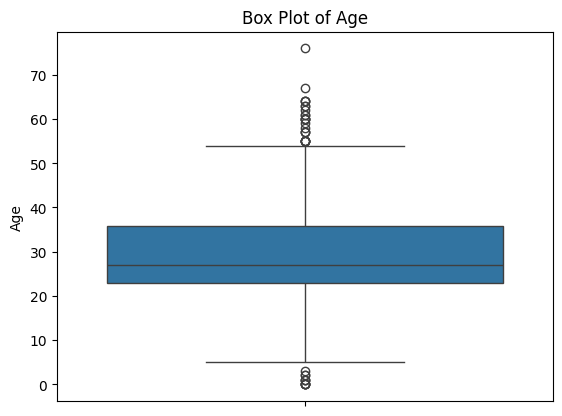

In [ ]:
#A box plot to visualize age and identify outliers
sns.boxplot(y=df['Age'])
plt.title('Box Plot of Age')
plt.ylabel('Age')


Text(0, 0.5, 'Fare')

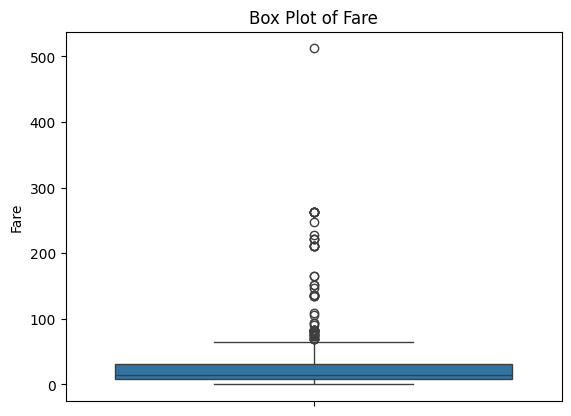

In [ ]:
#A box plot to visualize fare and identify outliers
sns.boxplot(y=df['Fare'])
plt.title('Box Plot of Fare')
plt.ylabel('Fare')


In [ ]:
#Data verification
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  418 non-null    int64   
 1   Survived     418 non-null    int64   
 2   Pclass       418 non-null    category
 3   Name         418 non-null    object  
 4   Sex          418 non-null    category
 5   Age          418 non-null    int64   
 6   SibSp        418 non-null    int64   
 7   Parch        418 non-null    int64   
 8   Ticket       418 non-null    object  
 9   Fare         418 non-null    float64 
 10  Cabin        418 non-null    category
 11  Embarked     418 non-null    category
dtypes: category(4), float64(1), int64(5), object(2)
memory usage: 30.9+ KB


STEP 5: UNIVARIATE ANALYSIS

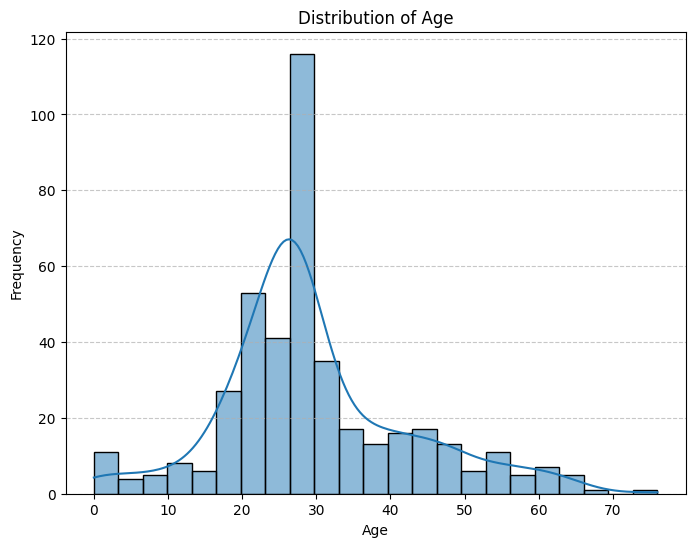

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(x='Age', data=df, kde=True)
plt.title(f'Distribution of Age') # Set the chart title
plt.xlabel('Age') # Set the x-axis label
plt.ylabel('Frequency') # Set the y-axis label
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid for better readability
plt.show() # Display the plot

Insight 1: Majority of the passengers are concentrated in the young to middle-age adult range, specifically between 20 and 35 years old, with a peak around 27-28 years old.

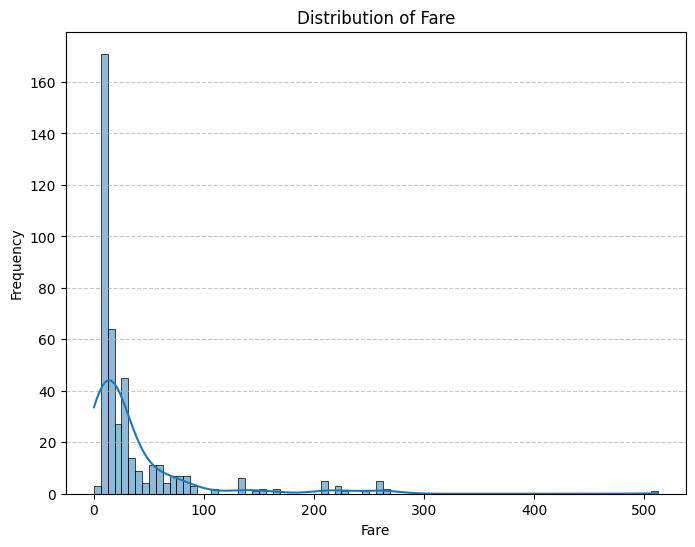

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(x='Fare', data=df, kde=True)
plt.title(f'Distribution of Fare') # Set the chart title
plt.xlabel('Fare') # Set the x-axis label
plt.ylabel('Frequency') # Set the y-axis label
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid for better readability
plt.show() # Display the plot

Insight 2: A significant majority of passengers paid lower fares, with a sharp decline in frequency as the fare increases.

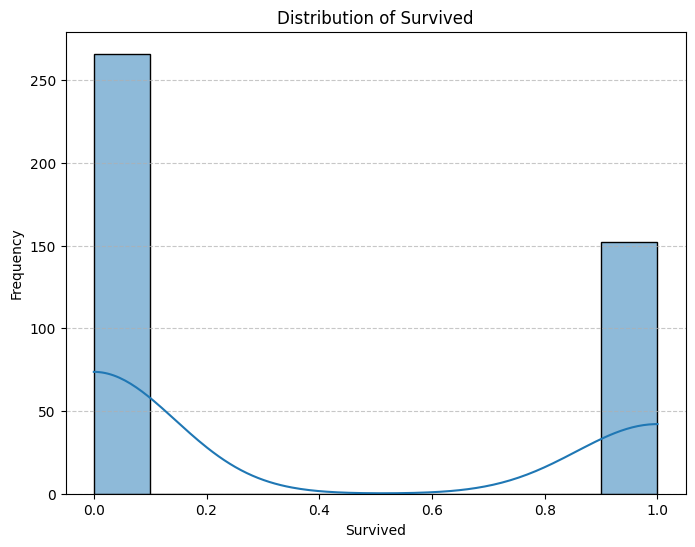

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(x='Survived', data=df, kde=True)
plt.title(f'Distribution of Survived') # Set the chart title
plt.xlabel('Survived') # Set the x-axis label
plt.ylabel('Frequency') # Set the y-axis label
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid for better readability
plt.show() # Display the plot

Insight 3: A greater number of passengers did not survive compared to those who survived. This indicates that there were more fatalities than survivors.

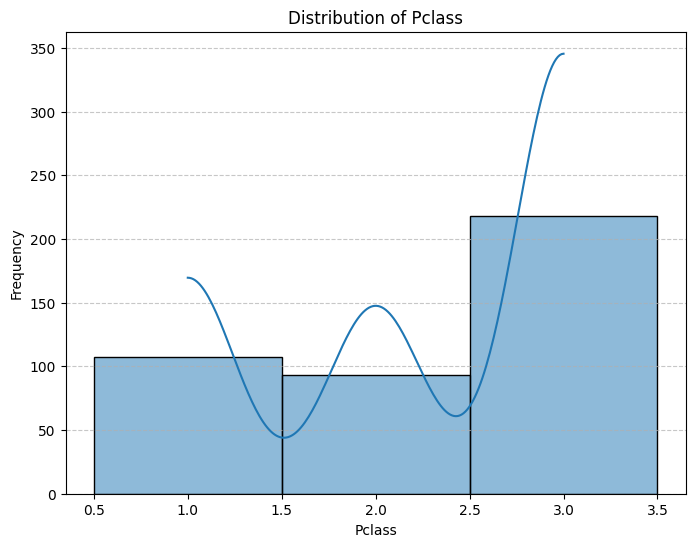

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(x='Pclass', data=df, kde=True)
plt.title(f'Distribution of Pclass') # Set the chart title
plt.xlabel('Pclass') # Set the x-axis label
plt.ylabel('Frequency') # Set the y-axis label
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid for better readability
plt.show() # Display the plot

Insight 4: There were significantly more third-class passengers compared to first and second class.

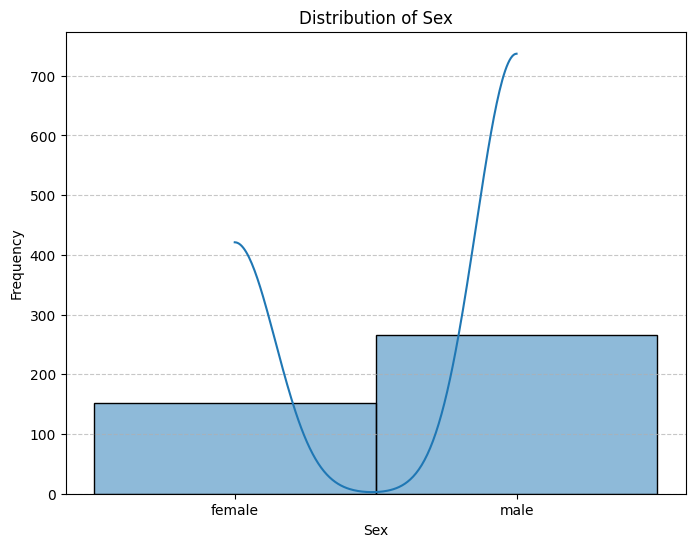

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(x='Sex', data=df, kde=True)
plt.title(f'Distribution of Sex') # Set the chart title
plt.xlabel('Sex') # Set the x-axis label
plt.ylabel('Frequency') # Set the y-axis label
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid for better readability
plt.show() # Display the plot

Insight 5: There are substantially more male pasengers than female passengers.

STEP 6: BIVARIATE ANALYSIS

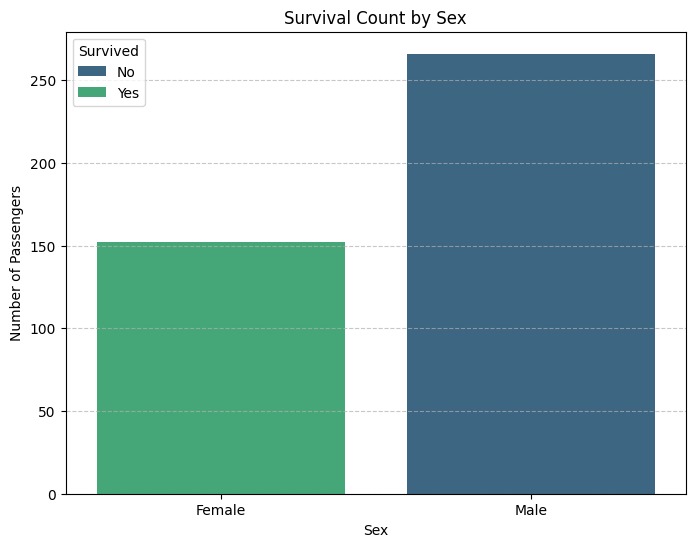

Interpretation: This chart clearly shows that a much higher proportion of females survived compared to males. This suggests a strong relationship between gender and survival rates.
Meaningful Relationship: Yes, there is a very meaningful relationship. 'Sex' appears to be a significant predictor of survival.


In [ ]:
# Create a count plot to visualize the relationship between 'Sex' and 'Survived'
# 'x' is 'Sex', 'hue' is 'Survived' to group bars by survival status, and 'data' is our DataFrame 'df'.
# palette='viridis' sets the color scheme.
plt.figure(figsize=(8, 6))
sns.countplot(x='Sex', hue='Survived', data=df, palette='viridis')
plt.title('Survival Count by Sex') # Set the chart title
plt.xlabel('Sex') # Set the x-axis label
plt.ylabel('Number of Passengers') # Set the y-axis label
plt.xticks(ticks=[0, 1], labels=['Female', 'Male']) # Custom x-axis labels for clarity
plt.legend(title='Survived', labels=['No', 'Yes']) # Add a legend for survival status
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid for readability
plt.show() # Display the plot

print("Interpretation: This chart clearly shows that a much higher proportion of females survived compared to males. This suggests a strong relationship between gender and survival rates.")
print("Meaningful Relationship: Yes, there is a very meaningful relationship. 'Sex' appears to be a significant predictor of survival.")

Insight 6: A much higher proportion of females survived compared to males. This suggests that 'Sex' was a strong predictor of survival on the Titanic, with females having a considerably better chance of survival than males.

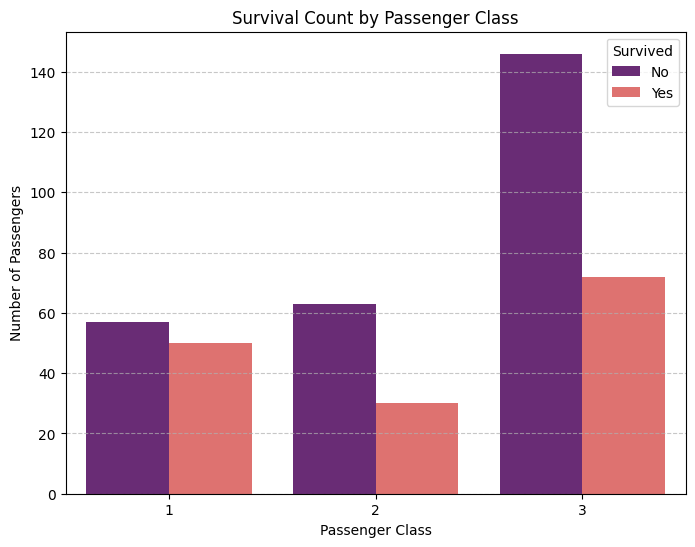

Interpretation: Passengers in 1st class had a much higher survival rate compared to 2nd and especially 3rd class. This indicates that higher class passengers had a greater chance of survival.
Meaningful Relationship: Yes, there is a strong and meaningful relationship between 'Pclass' and 'Survived'.


In [ ]:
# Create a count plot to visualize the relationship between 'Pclass' and 'Survived'
# 'x' is 'Pclass', 'hue' is 'Survived' to group bars by survival status, and 'data' is our DataFrame 'df'.
# palette='magma' sets the color scheme.
plt.figure(figsize=(8, 6))
sns.countplot(x='Pclass', hue='Survived', data=df, palette='magma')
plt.title('Survival Count by Passenger Class') # Set the chart title
plt.xlabel('Passenger Class') # Set the x-axis label
plt.ylabel('Number of Passengers') # Set the y-axis label
plt.legend(title='Survived', labels=['No', 'Yes']) # Add a legend for survival status
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid for readability
plt.show() # Display the plot

print("Interpretation: Passengers in 1st class had a much higher survival rate compared to 2nd and especially 3rd class. This indicates that higher class passengers had a greater chance of survival.")
print("Meaningful Relationship: Yes, there is a strong and meaningful relationship between 'Pclass' and 'Survived'.")

Insight 7: Passegers in the 1st class had a much higher rate of survival compared to those in 2nd and 3rd class. This suggests that higher class passengers had a gtreater chance of survival.

/tmp/ipykernel_1531/1128109494.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Survived', y='Age', data=df, palette='coolwarm')


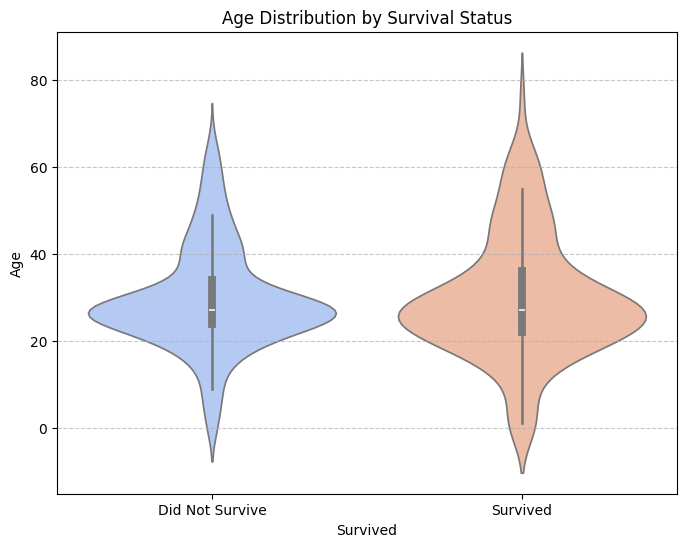

Interpretation: The vioin plot shows that the age distribution for those who survived has a slightly higher density at younger ages, particularly for children, compared to those who did not survive. The median age of survivors appears to be slightly lower than non-survivors.
Meaningful Relationship: Yes, there appears to be a meaningful relationship, with younger individuals (especially children) having a higher chance of survival.


In [ ]:
# Create a violin plot to visualize the distribution of 'Age' for 'Survived' and 'Not Survived'
# 'x' is 'Survived', 'y' is 'Age', and 'data' is our DataFrame 'df'.
# palette='coolwarm' sets the color scheme.
plt.figure(figsize=(8, 6))
sns.violinplot(x='Survived', y='Age', data=df, palette='coolwarm')
plt.title('Age Distribution by Survival Status') # Set the chart title
plt.xlabel('Survived') # Set the x-axis label
plt.ylabel('Age') # Set the y-axis label
plt.xticks(ticks=[0, 1], labels=['Did Not Survive', 'Survived']) # Custom x-axis labels
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid for readability
plt.show() # Display the plot

print("Interpretation: The vioin plot shows that the age distribution for those who survived has a slightly higher density at younger ages, particularly for children, compared to those who did not survive. The median age of survivors appears to be slightly lower than non-survivors.")
print("Meaningful Relationship: Yes, there appears to be a meaningful relationship, with younger individuals (especially children) having a higher chance of survival.")

Insight 8: The age distribution for those who survived has a slightly higher density at younger ages, particularly for children, compared to those who did not survive. The median age of survivors appears to be slightly lower than non-survivors. This indicates a meaningful relationship where younger individuals, especially children, had a higher chance of survival.



STEP 7: MULTIVARIATE ANALYSIS

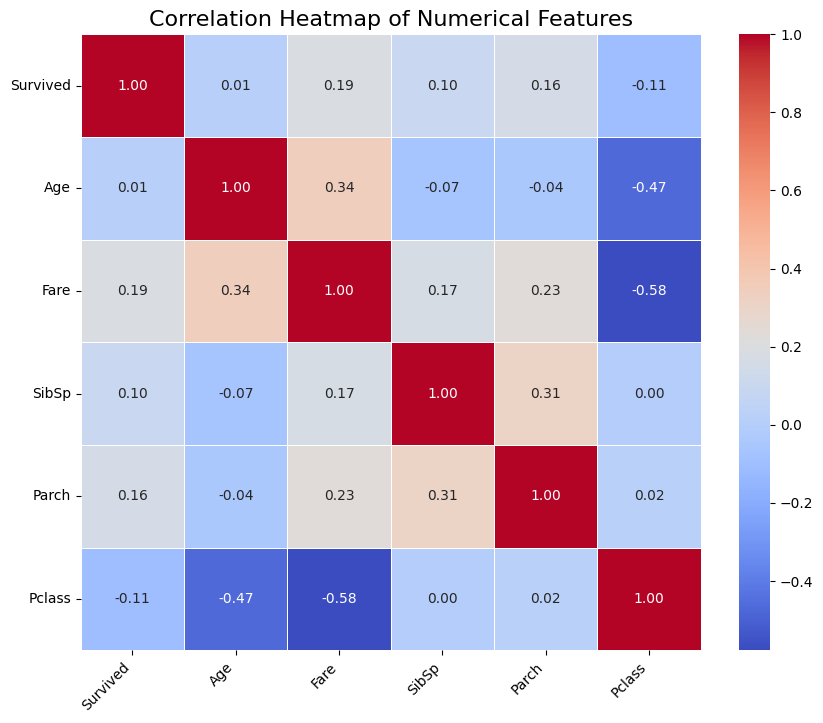

In [ ]:
numerical_features = ['Survived', 'Age', 'Fare', 'SibSp', 'Parch', 'Pclass']

# Calculate the pairwise correlation between selected numerical features.
# The .corr() method computes the standard correlation coefficient.
correlation_matrix = df[numerical_features].corr()

# Create a heatmap to visualize the correlation matrix.
plt.figure(figsize=(10, 8)) # Set the size of the plot for optimal readability.
sns.heatmap(correlation_matrix,
            annot=True,     # Display the correlation coefficients on the heatmap cells.
            cmap='coolwarm',  # Use a diverging colormap ('coolwarm' shows positive/negative correlations).
            fmt='.2f',      # Format the annotations to two decimal places.
            linewidths=.5)  # Add lines between cells for better visual separation.
plt.title('Correlation Heatmap of Numerical Features', fontsize=16) # Set a descriptive chart title.
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better legibility.
plt.yticks(rotation=0) # Ensure y-axis labels are horizontal.
plt.show() # Display the generated plot

Insight 9: 'Fare' shows a positive correlation with 'Survived' (0.19), suggesting that passengers who paid higher fares had a somewhat better chance of survival. Conversely, 'Pclass' has a negative correlation with 'Survived' (-0.11), indicating that lower passenger classes (higher Pclass number) are associated with a lower chance of survival, which aligns with previous observations. 'Age' shows a very weak positive correlation (0.01) with 'Survived', implying that age, in its raw numerical form, has very little linear relationship. Additionally, 'Pclass' has strong negative correlations with both 'Age' (-0.47) and 'Fare' (-0.58), which means higher passenger classes (Pclass 1) are associated with older ages and significantly higher fares.

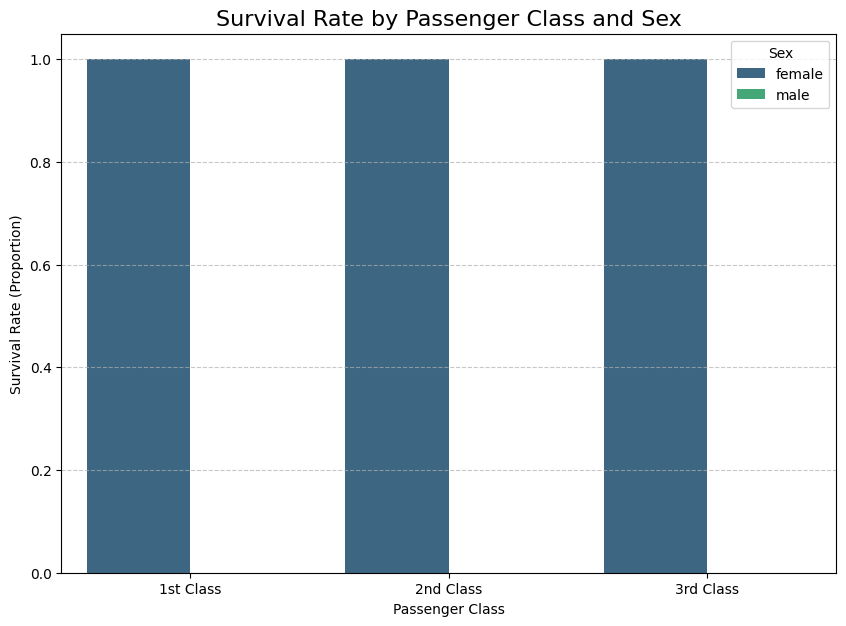

In [ ]:
# Calculate the mean survival rate grouped by 'Pclass' and 'Sex'.
# This aggregates the data to show the proportion of survivors (mean of 'Survived')
# for each unique combination of passenger class and gender.
# setting observed=False ensures that all categories, even those not present in a subgroup, are shown.
mean_survival_pclass_sex = df.groupby(['Pclass', 'Sex'], observed=False)['Survived'].mean().reset_index()

# Create a grouped bar plot to visualize the survival rate.
# 'x' represents Pclass on the horizontal axis.
# 'y' represents the calculated mean 'Survived' (survival rate) on the vertical axis.
# 'hue' is set to 'Sex' to create separate bars for 'male' and 'female' within each Pclass group.
plt.figure(figsize=(10, 7)) # Set the size of the plot for better readability.
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=mean_survival_pclass_sex, palette='viridis')
plt.title('Survival Rate by Passenger Class and Sex', fontsize=16) # Set a descriptive chart title.
plt.xlabel('Passenger Class') # Set the x-axis label.
plt.ylabel('Survival Rate (Proportion)') # Set the y-axis label.
# Customize x-axis tick labels for clarity.
plt.xticks(ticks=[0, 1, 2], labels=['1st Class', '2nd Class', '3rd Class'])
plt.legend(title='Sex') # Add a legend to distinguish between male and female bars.
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a horizontal grid for easier comparison of rates.
plt.show() # Display the generated plot.

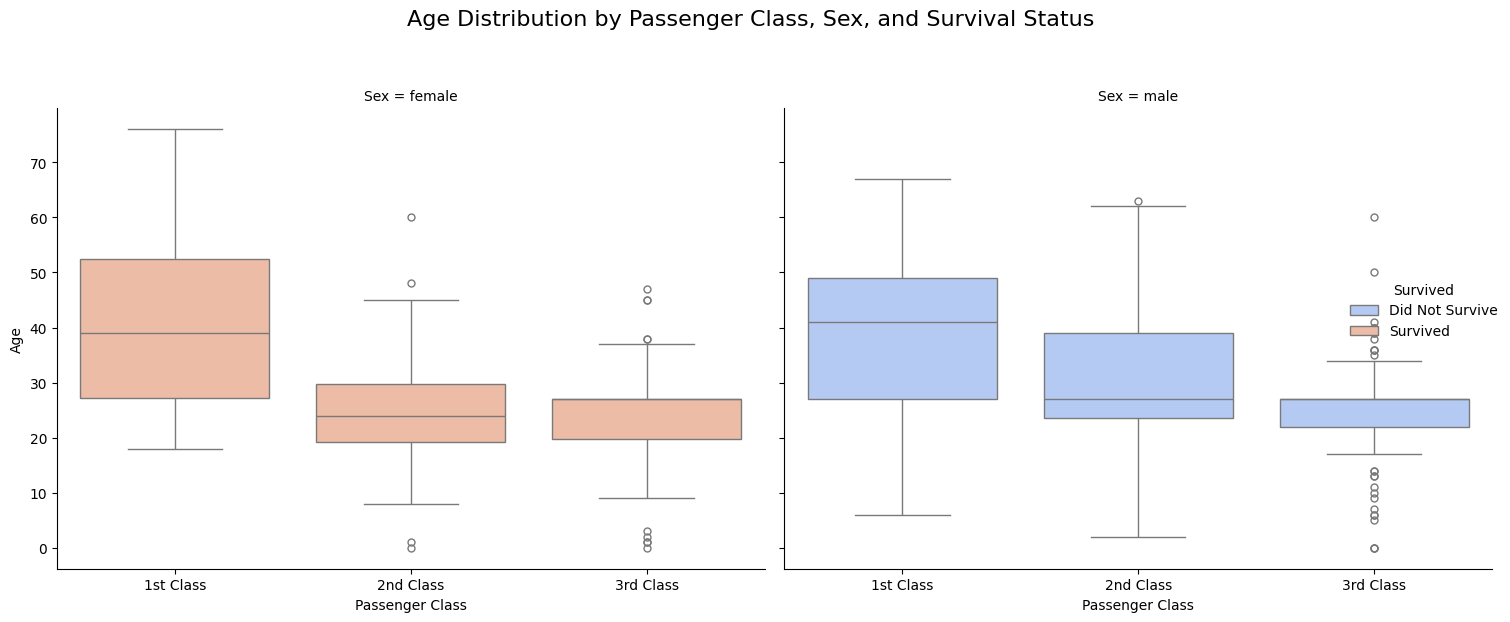

In [ ]:
# Create a grouped box plot to visualize Age distribution by Pclass, Sex, and Survived.
# sns.catplot is used here because it effectively handles faceting (creating separate subplots for 'col' variable).
# 'x' represents 'Pclass', 'y' represents 'Age', 'hue' differentiates by 'Survived' status,
# and 'col' creates separate subplots for each 'Sex'.
# kind='box' specifies that the plot type within each facet should be a box plot.

g = sns.catplot(x='Pclass', y='Age', hue='Survived', col='Sex', data=df, kind='box',
                height=6, aspect=1.2, palette='coolwarm') # Adjust height and aspect for better readability and layout.
g.set_axis_labels('Passenger Class', 'Age') # Set common axis labels for the entire plot.
g.set_titles('Sex = {col_name}') # Set titles for each facet (column) to indicate the gender.

# Customize x-axis labels for clarity on each subplot.
new_xticks = ['1st Class', '2nd Class', '3rd Class']
for ax in g.axes.flat:
    ax.set_xticks(range(len(new_xticks))) # Set numerical tick locations explicitly.
    ax.set_xticklabels(new_xticks)

g._legend.set_title('Survived') # Set the title for the hue legend.
# Update legend labels to be more descriptive.
for t, l in zip(g._legend.texts, ['Did Not Survive', 'Survived']):
    t.set_text(l)

plt.suptitle('Age Distribution by Passenger Class, Sex, and Survival Status', y=1.03, fontsize=16) # Set an overall title for the entire figure.
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent titles and labels from overlapping.
plt.show() # Display the generated plot.


Insight 10: The age distribution of survivors varies significantly across passenger class and sex. In 1st class, surviving females tend to be slightly older than those who did not survive. In 3rd class, however, younger females (including children) appear to have a higher survival rate compared to older females. Similarly, in 3rd class, surviving males show a considerably younger age distribution (often including children) compared to non-surviving males. In contrast, for 1st class males, the age distribution for survivors appears to be slightly older than non-survivors.
Across all passenger classes, there's a noticeable presence of young children among the survivors, particularly prominent in 3rd class for both sexes, suggesting a 'children first' principle might have influenced survival outcomes in certain contexts, even within lower classes. First-class passengers, both male and female, generally have a wider and older age distribution compared to those in 3rd class.

## Key Insights from Data Analysis

1.  The majority of passengers were male, primarily falling within the young to middle-age adult range (20-35 years). The largest passenger demographic was represented by the third class.

2.  The dataset reveals a heavily skewed fare distribution, with most passengers having paid lower prices, indicating a prevalence of more economical travel options.

3.  A higher number of passengers did not survive compared to those who did, suggesting a significant loss of life.


5.  Passenger class was a strong determinant of survival outcomes. First-class passengers exhibited a significantly higher survival rate compared to those in second and especially third class. This is corroborated by a negative correlation between passenger class and survival probability.

6.   While there is a very weak direct linear correlation between `Age` and `Survived`, `Fare` shows a positive correlation with survival. This suggests that passengers who paid higher fares had an increased likelihood of survival, which is likely linked to their higher social class and potentially better access to lifeboats. Higher passenger classes are also associated with older ages and significantly higher fares.

7.  Younger individuals, particularly children, demonstrate a higher propensity for survival across various classes, most prominently in third class for both sexes. Conversely, within first class, both male and female survivors tend to be slightly older than their non-surviving counterparts in that class.

**Recommendations**:

1.  **Prioritize Safety Protocols for Vulnerable Demographics (Females and Children)**.
    *   **Supporting Evidence**: Analysis revealed significantly higher survival rates for females and younger individuals, particularly children, indicating an existing, albeit informal, prioritization in crisis.
    *   **Business Rationale**: Formalizing and enhancing 'women and children first' safety protocols ensures ethical and effective crisis management, potentially maximizing survival rates for the most vulnerable populations and bolstering organizational reputation and trust.

2.  **Implement Tiered Safety Measures to Ensure Equitable Access to Resources**.
    *   **Supporting Evidence**: Insights 7 and 9 demonstrate a strong correlation between higher passenger class/fare and increased survival rates. First-class passengers had significantly better survival chances, suggesting differential access to critical safety resources.
    *   **Business Rationale**: To mitigate risks associated with socioeconomic disparities in safety outcomes, future designs must ensure equitable access to life-saving resources, or, if tiered service models persist, clearly articulate varying safety provisions to manage stakeholder expectations and regulatory compliance.

3.  **Conduct a Detailed Post-Incident Analysis of Resource Allocation and Crisis Communicatio**n.
    *   **Supporting Evidence**: The observed overall low survival rate combined with the stark disparities across sex and passenger class, points to potential inefficiencies or biases in emergency response and resource distribution.
    *   **Business Rationale**: A thorough analysis of how safety resources (e.g., lifeboats, evacuation routes) were distributed and communicated to different passenger segments is crucial. This will inform the development of more robust, transparent, and equitable emergency response plans for future operations.

4.   **Develop Targeted Safety Training and Communication Strategies for Diverse Passenger Segments**.
     *   **Supporting Evidence**: The majority of passengers were young to middle-aged males in third class, who experienced substantially lower survival rates. This demographic may not have been effectively reached by existing safety measures.
      *   **Business Rationale**: Tailored safety campaigns and onboard training, designed to resonate with demographics demonstrating lower survival rates, can significantly improve emergency preparedness and overall survival outcomes across all passenger segments.

5. **Re-evaluate and Standardize Emergency Evacuation Procedures for Universal Effectiveness**.

    *   **Supporting Evidence**: The high number of fatalities and the strong predictive power of factors like sex and passenger class on survival indicate that the emergency procedures were either inadequate or inconsistently applied.
    *   **Business Rationale**: A comprehensive review and standardization of evacuation procedures are essential. This ensures clear, accessible instructions and fair, efficient implementation for all passengers, irrespective of their background, thereby enhancing overall safety and minimizing potential casualties in future incidents.

### **Executive Summary: Analysis of Titanic Survival Factors**

**Business Problem :** The organization experienced a catastrophic incident resulting in significant loss of life. Preliminary data suggests survival outcomes were not evenly distributed across passenger groups_ raising concerns about whether emergency resources, safety protocols and crisis communication were fairly and effectively administered across all passenger segments.

**Purpose of Analysis:** This analysis aims to identify key demographic and socio-economic factors influencing passenger survival during the Titanic disaster. Understanding these relationships provides crucial insights to evaluate modern safety standards and crisis management strategies, fostering more resilient and equitable approaches to passenger welfare.

**Dataset Description:** The dataset comprises detailed information on individual Titanic passengers, including their survival status, passenger class, gender, age, and the fare paid. This rich data allows for a comprehensive, data-driven examination of the dynamics underpinning survival probabilities.

**Key Findings:** Our exploratory data analysis revealed that survival was significantly influenced by gender and passenger class. Female passengers consistently exhibited higher survival rates than males. Furthermore, first-class passengers showed a substantially greater likelihood of survival compared to those in second and third classes, indicating that socio-economic status, reflected by fare and class, played a crucial role in survival outcomes. While raw age showed a weak direct correlation, a nuanced view indicated that younger individuals, especially children, had an elevated chance of survival. Conversely, among first-class passengers, survivors (both male and female) tended to be slightly older than their non-surviving counterparts within that class.

**Overall Business Implications:** These findings underscore the critical need for equitable and well-defined safety protocols that transcend demographic and socio-economic biases. Organizations in passenger transport or crisis management must thoroughly evaluate their emergency response frameworks to ensure fairness, transparency, and effective communication to all individuals. Prioritizing vulnerable populations and ensuring universal access to safety measures are paramount for both ethical conduct and maintaining public trust and operational resilience.

**Conclusion:** Survival during the Titanic disaster was not a random event but was profoundly shaped by an interplay of gender and social class. These historical insights are invaluable for continuously improving and reinforcing modern safety strategies, ultimately safeguarding passenger well-being and operational integrity in future critical situations.